# 📊 Bitcoin Sentiment vs Trader Performance Analysis
### Hyperliquid Historical Trades × Fear & Greed Index

**Objective:** Explore how market sentiment (Fear/Greed) correlates with trader behaviour and profitability on Hyperliquid.

**Datasets:**
- `historical_data.csv` — 211,224 trades across 32 accounts, 246 coins (Jan–Dec 2024)
- `fear_greed_index.csv` — Daily Fear & Greed Index values (2018–2025)

**Key Questions:**
1. Do traders profit more during Fear or Greed?
2. How does trade volume/size shift with sentiment?
3. Who are the top performers, and do they exploit sentiment?
4. Are there hidden patterns in liquidations, long/short bias, and timing?


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'axes.titlecolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.6,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'font.size':        11,
})

SENTIMENT_COLORS = {
    'Extreme Fear': '#ef4444',
    'Fear':         '#f97316',
    'Neutral':      '#eab308',
    'Greed':        '#22c55e',
    'Extreme Greed':'#16a34a',
}
SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

print("✅ Libraries loaded.")


✅ Libraries loaded.


## 2. Load & Preview Data

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
trades = pd.read_csv('historical_data.csv')
fg     = pd.read_csv('fear_greed_index.csv')

print(f"Trades shape : {trades.shape}")
print(f"FG Index shape: {fg.shape}")
trades.head(3)


Trades shape : (211224, 16)
FG Index shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


In [3]:
fg.head(3)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


## 3. Data Cleaning & Merging

In [4]:
# ── Parse dates ───────────────────────────────────────────────────────────────
trades['datetime'] = pd.to_datetime(trades['Timestamp IST'],
                                     format='%d-%m-%Y %H:%M', errors='coerce')
trades['date']     = trades['datetime'].dt.date.astype(str)

fg['date'] = pd.to_datetime(fg['date']).dt.strftime('%Y-%m-%d')

# ── Merge on date ──────────────────────────────────────────────────────────────
merged = trades.merge(fg[['date', 'value', 'classification']], on='date', how='left')

print(f"Merged rows : {len(merged):,}")
print(f"Coverage    : {merged['classification'].notna().mean():.1%} of trades have a sentiment label")
print()
print("Sentiment distribution of trades:")
print(merged['classification'].value_counts())


Merged rows : 211,224
Coverage    : 100.0% of trades have a sentiment label

Sentiment distribution of trades:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [5]:
# ── Feature engineering ───────────────────────────────────────────────────────
merged['is_close'] = merged['Direction'].str.contains('Close|Settlement|Liquidat',
                                                       case=False, na=False)
merged['is_long']  = merged['Direction'].str.contains('Long|Buy', case=False, na=False)
merged['is_short'] = merged['Direction'].str.contains('Short|Sell', case=False, na=False)

# Realised PnL trades only
closed = merged[merged['Closed PnL'] != 0].copy()
closed['win'] = closed['Closed PnL'] > 0

print(f"Closing trades (non-zero PnL): {len(closed):,}")
print(f"Win rate (overall)           : {closed['win'].mean():.2%}")
print(f"Avg PnL per close            : ${closed['Closed PnL'].mean():,.2f}")


Closing trades (non-zero PnL): 104,408
Win rate (overall)           : 83.20%
Avg PnL per close            : $98.62


## 4. Exploratory Data Analysis

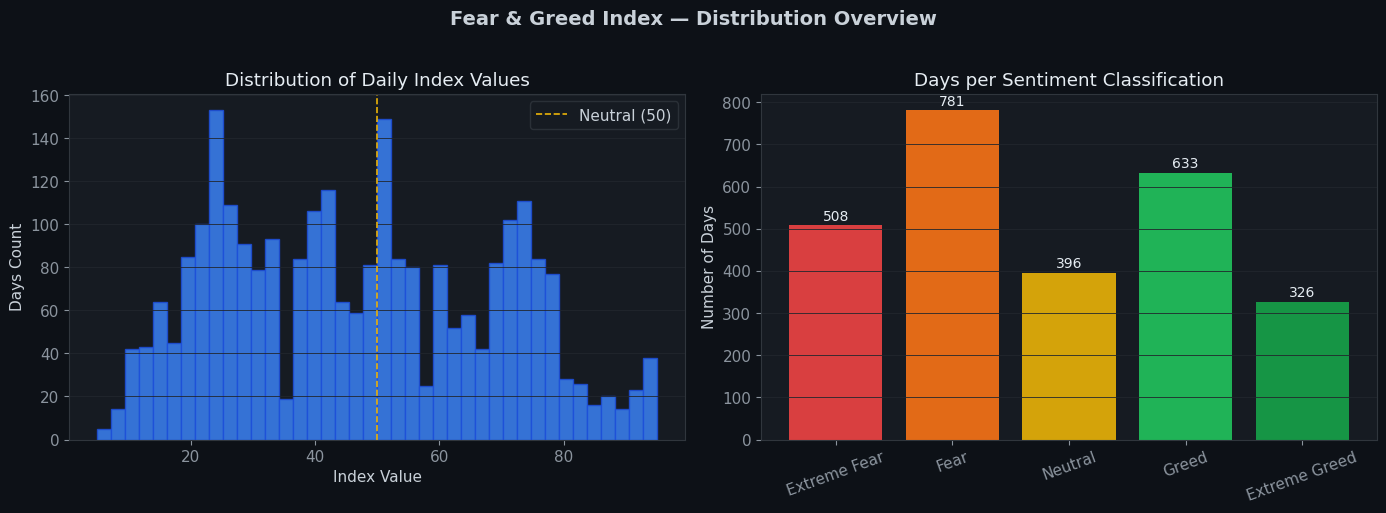

Saved → fig_01_fg_distribution.png


In [6]:
# ── 4.1  Distribution of Fear & Greed ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fear & Greed Index — Distribution Overview', fontsize=14, fontweight='bold', y=1.02)

# Daily values histogram
ax = axes[0]
ax.hist(fg['value'], bins=40, color='#3b82f6', edgecolor='#1d4ed8', alpha=0.85)
ax.set_xlabel('Index Value')
ax.set_ylabel('Days Count')
ax.set_title('Distribution of Daily Index Values')
ax.axvline(50, color='#eab308', linestyle='--', linewidth=1.2, label='Neutral (50)')
ax.legend()
ax.grid(True, axis='y')

# Sentiment label breakdown
ax2 = axes[1]
counts = fg['classification'].value_counts().reindex(SENTIMENT_ORDER)
bars = ax2.bar(counts.index, counts.values,
               color=[SENTIMENT_COLORS[c] for c in counts.index], edgecolor='none', alpha=0.9)
ax2.set_title('Days per Sentiment Classification')
ax2.set_ylabel('Number of Days')
ax2.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=10, color='#e6edf3')
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('fig_01_fg_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("Saved → fig_01_fg_distribution.png")


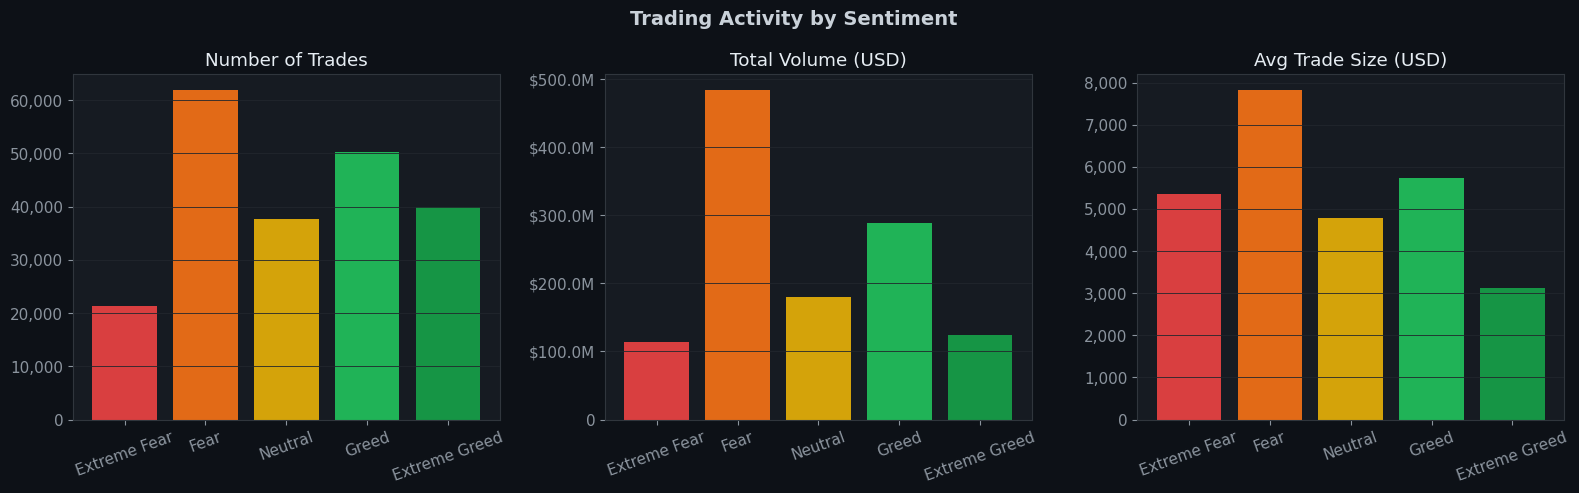

In [7]:
# ── 4.2  Trade volume by sentiment ────────────────────────────────────────────
vol = (merged.groupby('classification')['Size USD']
       .agg(['sum','mean','count'])
       .reindex(SENTIMENT_ORDER)
       .dropna())
vol.columns = ['Total Volume (USD)', 'Avg Trade Size (USD)', 'Trade Count']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Trading Activity by Sentiment', fontsize=14, fontweight='bold')

cols   = ['Trade Count', 'Total Volume (USD)', 'Avg Trade Size (USD)']
titles = ['Number of Trades', 'Total Volume (USD)', 'Avg Trade Size (USD)']
for ax, col, title in zip(axes, cols, titles):
    colors = [SENTIMENT_COLORS[c] for c in vol.index]
    bars = ax.bar(vol.index, vol[col], color=colors, alpha=0.9, edgecolor='none')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, axis='y')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'${x/1e9:.1f}B' if x >= 1e9 else (f'${x/1e6:.1f}M' if x >= 1e6 else f'{x:,.0f}')))

plt.tight_layout()
plt.savefig('fig_02_volume_by_sentiment.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()


## 5. PnL vs Market Sentiment

In [8]:
# ── 5.1  Win rate & avg PnL per sentiment ────────────────────────────────────
pnl_stats = (closed.groupby('classification')
             .agg(
                 win_rate   = ('win', 'mean'),
                 avg_pnl    = ('Closed PnL', 'mean'),
                 median_pnl = ('Closed PnL', 'median'),
                 total_pnl  = ('Closed PnL', 'sum'),
                 trades     = ('Closed PnL', 'count')
             )
             .reindex(SENTIMENT_ORDER)
             .dropna())

print(pnl_stats.round(2).to_string())


                win_rate  avg_pnl  median_pnl   total_pnl  trades
classification                                                   
Extreme Fear        0.76    71.03        6.39   739110.25   10406
Fear                0.87   112.63        6.35  3357155.44   29808
Neutral             0.82    71.20        4.58  1292920.68   18159
Greed               0.77    85.40        4.93  2150129.27   25176
Extreme Greed       0.89   130.21        8.53  2715171.31   20853


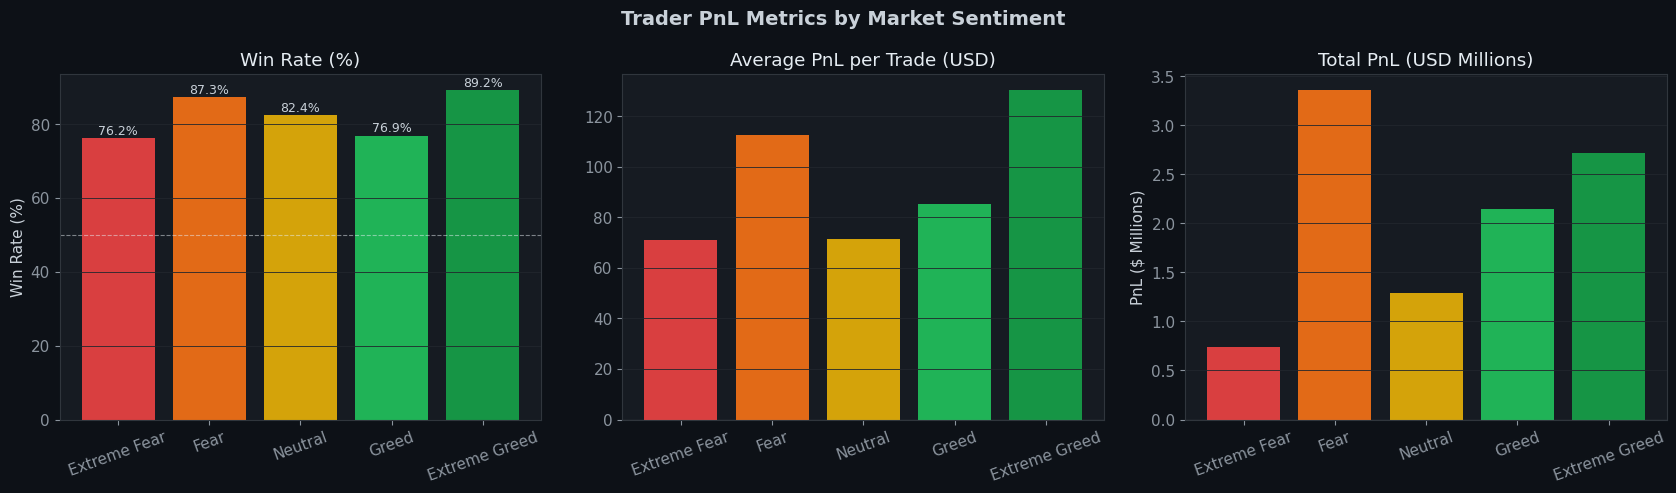

In [9]:
# ── 5.2  Visualise PnL metrics by sentiment ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Trader PnL Metrics by Market Sentiment', fontsize=14, fontweight='bold')

colors = [SENTIMENT_COLORS[c] for c in pnl_stats.index]

# Win rate
ax = axes[0]
bars = ax.bar(pnl_stats.index, pnl_stats['win_rate'] * 100, color=colors, alpha=0.9)
ax.set_title('Win Rate (%)')
ax.set_ylabel('Win Rate (%)')
ax.tick_params(axis='x', rotation=20)
ax.axhline(50, color='#e6edf3', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(True, axis='y')
for bar, val in zip(bars, pnl_stats['win_rate'] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Avg PnL
ax2 = axes[1]
bar_colors = ['#ef4444' if v < 0 else c for v, c in zip(pnl_stats['avg_pnl'], colors)]
bars2 = ax2.bar(pnl_stats.index, pnl_stats['avg_pnl'], color=bar_colors, alpha=0.9)
ax2.set_title('Average PnL per Trade (USD)')
ax2.tick_params(axis='x', rotation=20)
ax2.axhline(0, color='#e6edf3', linewidth=0.8, alpha=0.5)
ax2.grid(True, axis='y')

# Total PnL
ax3 = axes[2]
bar_colors3 = ['#ef4444' if v < 0 else c for v, c in zip(pnl_stats['total_pnl'], colors)]
bars3 = ax3.bar(pnl_stats.index, pnl_stats['total_pnl'] / 1e6, color=bar_colors3, alpha=0.9)
ax3.set_title('Total PnL (USD Millions)')
ax3.set_ylabel('PnL ($ Millions)')
ax3.tick_params(axis='x', rotation=20)
ax3.axhline(0, color='#e6edf3', linewidth=0.8, alpha=0.5)
ax3.grid(True, axis='y')

plt.tight_layout()
plt.savefig('fig_03_pnl_by_sentiment.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()


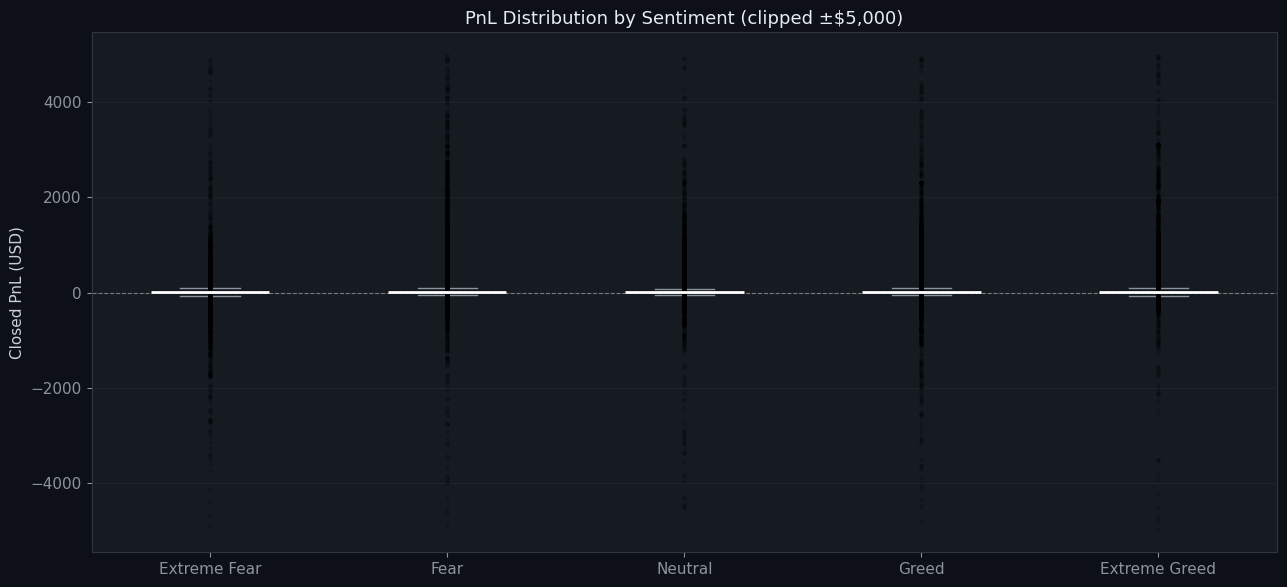

In [10]:
# ── 5.3  PnL distribution boxplot ────────────────────────────────────────────
clipped = closed[closed['Closed PnL'].between(-5000, 5000)].copy()

fig, ax = plt.subplots(figsize=(13, 6))
box_data  = [clipped[clipped['classification'] == s]['Closed PnL'].dropna().values
             for s in SENTIMENT_ORDER if s in clipped['classification'].unique()]
box_labels = [s for s in SENTIMENT_ORDER if s in clipped['classification'].unique()]

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='#8b949e'),
                capprops=dict(color='#8b949e'),
                flierprops=dict(marker='o', color='#8b949e', alpha=0.2, markersize=2))

for patch, label in zip(bp['boxes'], box_labels):
    patch.set_facecolor(SENTIMENT_COLORS[label])
    patch.set_alpha(0.7)

ax.axhline(0, color='white', linestyle='--', linewidth=0.8, alpha=0.4)
ax.set_title('PnL Distribution by Sentiment (clipped ±$5,000)', fontsize=13)
ax.set_ylabel('Closed PnL (USD)')
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('fig_04_pnl_boxplot.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()


## 6. Long / Short Bias by Sentiment

In [11]:
# ── 6.1  Long vs Short ratio per sentiment ───────────────────────────────────
direction_map = {
    'Open Long' : 'Long', 'Close Long' : 'Long', 'Long > Short': 'Long',
    'Open Short': 'Short','Close Short': 'Short','Short > Long': 'Short',
    'Buy'       : 'Long', 'Sell'       : 'Short',
}
merged['side_clean'] = merged['Direction'].map(direction_map)

ls = (merged[merged['side_clean'].isin(['Long','Short'])]
      .groupby(['classification','side_clean'])
      .size()
      .unstack(fill_value=0)
      .reindex(SENTIMENT_ORDER)
      .dropna())

ls['Total'] = ls.sum(axis=1)
ls['Long %'] = ls['Long'] / ls['Total'] * 100
ls['Short %'] = ls['Short'] / ls['Total'] * 100

print(ls[['Long','Short','Long %','Short %']].round(1).to_string())


side_clean       Long  Short  Long %  Short %
classification                               
Extreme Fear    14058   7339    65.7     34.3
Fear            38305  23490    62.0     38.0
Neutral         23115  14561    61.4     38.6
Greed           21243  28995    42.3     57.7
Extreme Greed   18625  21335    46.6     53.4


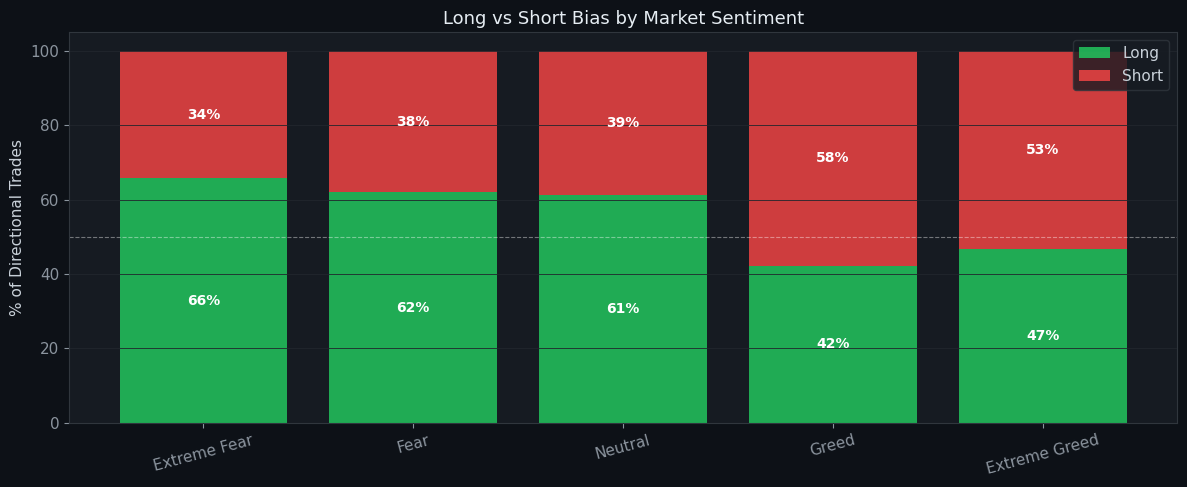

In [12]:
# ── 6.2  Stacked bar: long/short bias ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(ls))
ax.bar(x, ls['Long %'],  color='#22c55e', alpha=0.85, label='Long')
ax.bar(x, ls['Short %'], bottom=ls['Long %'], color='#ef4444', alpha=0.85, label='Short')
ax.set_xticks(list(x))
ax.set_xticklabels(ls.index, rotation=15)
ax.set_ylabel('% of Directional Trades')
ax.set_title('Long vs Short Bias by Market Sentiment', fontsize=13)
ax.axhline(50, color='white', linestyle='--', linewidth=0.8, alpha=0.4)
ax.legend()
ax.grid(True, axis='y')
for i, (lp, sp) in enumerate(zip(ls['Long %'], ls['Short %'])):
    ax.text(i, lp/2, f'{lp:.0f}%', ha='center', va='center',
            color='white', fontsize=10, fontweight='bold')
    ax.text(i, lp + sp/2, f'{sp:.0f}%', ha='center', va='center',
            color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_05_long_short_bias.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()


## 7. Top Trader Analysis

In [13]:
# ── 7.1  Leaderboard ─────────────────────────────────────────────────────────
trader_stats = (closed.groupby('Account')
                .agg(
                    total_pnl  = ('Closed PnL','sum'),
                    avg_pnl    = ('Closed PnL','mean'),
                    win_rate   = ('win','mean'),
                    trades     = ('Closed PnL','count'),
                    total_fees = ('Fee','sum'),
                )
                .sort_values('total_pnl', ascending=False))

trader_stats['net_pnl'] = trader_stats['total_pnl'] - trader_stats['total_fees']
trader_stats['short_account'] = trader_stats.index.str[:8] + '…'

print("=== TOP 10 TRADERS BY TOTAL PnL ===")
print(trader_stats.head(10)[['total_pnl','net_pnl','win_rate','trades','total_fees']].round(2).to_string())


=== TOP 10 TRADERS BY TOTAL PnL ===
                                             total_pnl     net_pnl  win_rate  trades  total_fees
Account                                                                                         
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2143382.60  2136334.37      0.79    6279     7048.23
0x083384f897ee0f19899168e3b1bec365f52a9012  1600229.82  1596585.48      0.79    1732     3644.34
0xbaaaf6571ab7d571043ff1e313a9609a10637864   940163.81   934748.56      0.99    9997     5415.25
0x513b8629fe877bb581bf244e326a047b249c4ff1   840422.56   803064.61      0.90    5482    37357.95
0xbee1707d6b44d4d52bfe19e41f8a828645437aab   836080.55   827391.91      0.76   22551     8688.64
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4   677747.05   673290.47      0.95    2233     4456.58
0x72743ae2822edd658c0c50608fd7c5c501b2afbd   429355.57   428738.04      0.75     737      617.53
0x430f09841d65beb3f27765503d0f850b8bce7713   416541.87   416289.15      1.00     599      2

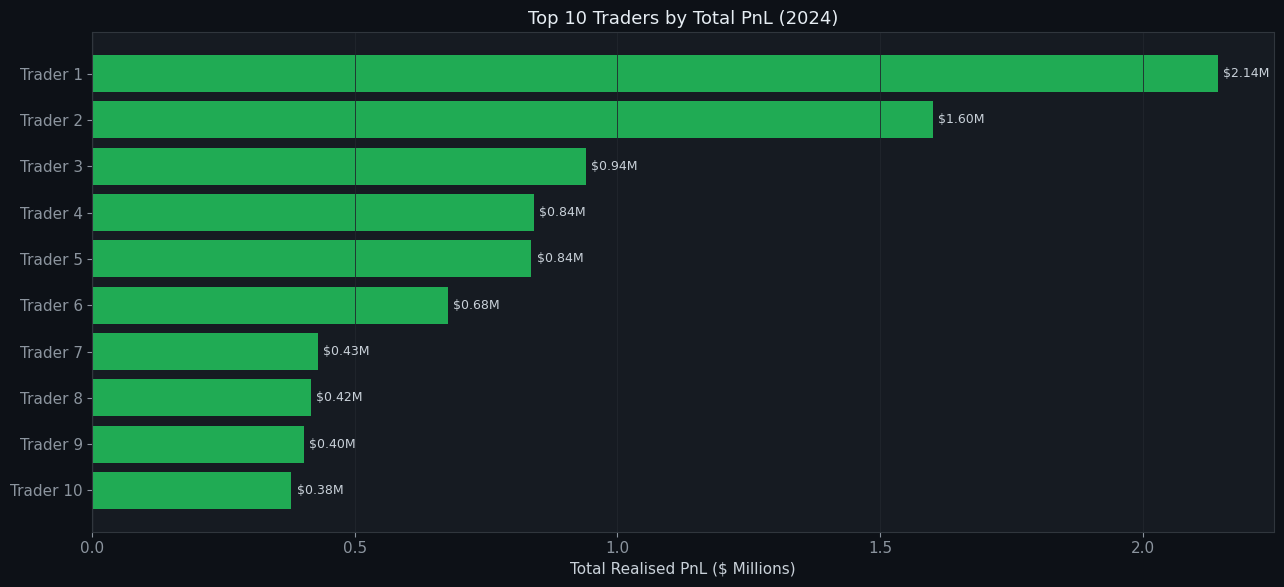

In [14]:
# ── 7.2  Top 10 PnL bar ──────────────────────────────────────────────────────
top10 = trader_stats.head(10).copy()
top10['label'] = [f'Trader {i+1}' for i in range(len(top10))]

fig, ax = plt.subplots(figsize=(13, 6))
colors_bar = ['#22c55e' if v > 0 else '#ef4444' for v in top10['total_pnl']]
bars = ax.barh(top10['label'][::-1], top10['total_pnl'][::-1] / 1e6, color=colors_bar[::-1], alpha=0.85)
ax.set_xlabel('Total Realised PnL ($ Millions)')
ax.set_title('Top 10 Traders by Total PnL (2024)', fontsize=13)
ax.axvline(0, color='white', linewidth=0.8, alpha=0.4)
ax.grid(True, axis='x')
for bar, val in zip(bars, top10['total_pnl'][::-1] / 1e6):
    offset = 0.01 if val >= 0 else -0.01
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'${val:.2f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_06_top_traders.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()


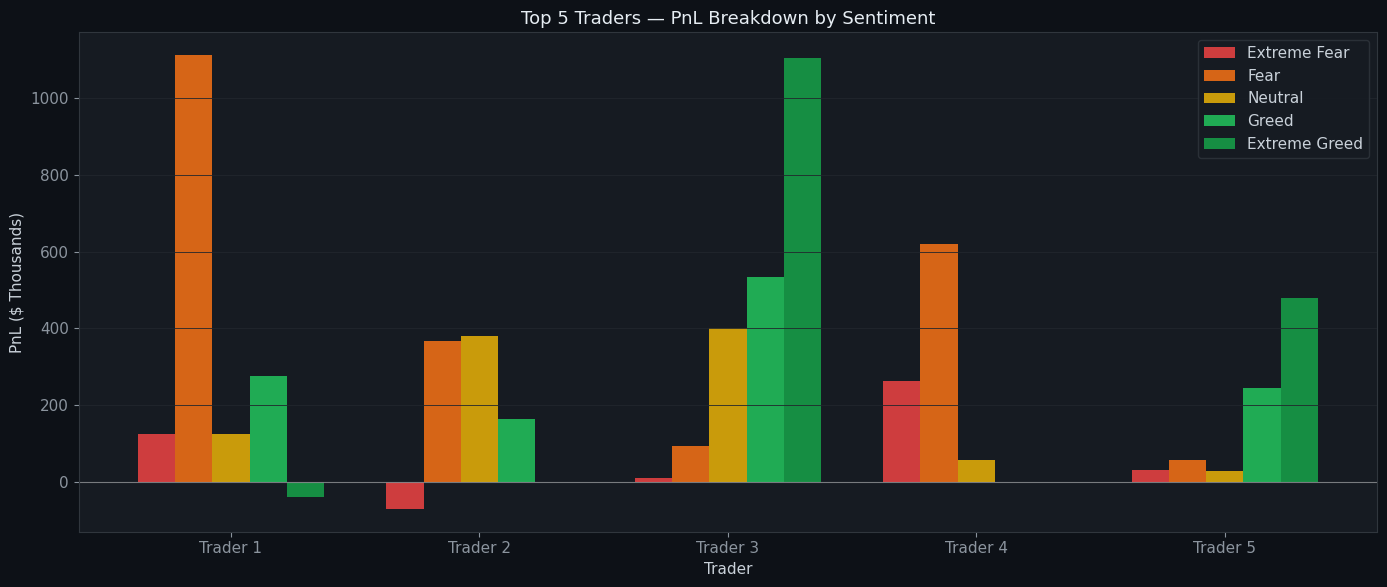

In [15]:
# ── 7.3  Top traders: PnL breakdown by sentiment ─────────────────────────────
top5_accounts = trader_stats.head(5).index.tolist()
top5_data = (closed[closed['Account'].isin(top5_accounts)]
             .groupby(['Account','classification'])['Closed PnL']
             .sum()
             .unstack(fill_value=0)
             .reindex(columns=SENTIMENT_ORDER, fill_value=0))

top5_data.index = [f'Trader {i+1}' for i in range(len(top5_data))]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(top5_data))
width = 0.15
for i, sentiment in enumerate(SENTIMENT_ORDER):
    if sentiment in top5_data.columns:
        ax.bar(x + i * width, top5_data[sentiment] / 1e3,
               width, label=sentiment,
               color=SENTIMENT_COLORS[sentiment], alpha=0.85)

ax.set_xlabel('Trader')
ax.set_ylabel('PnL ($ Thousands)')
ax.set_title('Top 5 Traders — PnL Breakdown by Sentiment', fontsize=13)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(top5_data.index)
ax.axhline(0, color='white', linewidth=0.8, alpha=0.4)
ax.legend(loc='upper right')
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('fig_07_top5_sentiment_pnl.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()


## 8. Time-Series: Sentiment vs Daily PnL

In [16]:
# ── 8.1  Daily aggregates ─────────────────────────────────────────────────────
daily = (closed.groupby('date')
         .agg(total_pnl=('Closed PnL','sum'),
              trades=('Closed PnL','count'),
              win_rate=('win','mean'))
         .reset_index())
daily = daily.merge(fg[['date','value','classification']], on='date', how='left')
daily['date_dt'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date_dt')

# 7-day rolling PnL
daily['pnl_7d'] = daily['total_pnl'].rolling(7, min_periods=1).mean()

print(f"Daily rows: {len(daily)}")
daily.head(3)


Daily rows: 420


,date,total_pnl,trades,win_rate,value,classification,date_dt,pnl_7d
0,2023-12-14,-205.434737,6,0.666667,72.0,Greed,2023-12-14,-205.434737
1,2023-12-15,-24.632034,2,0.000000,70.0,Greed,2023-12-15,-115.033386
2,2023-12-17,304.982785,11,0.636364,73.0,Greed,2023-12-17,24.972005


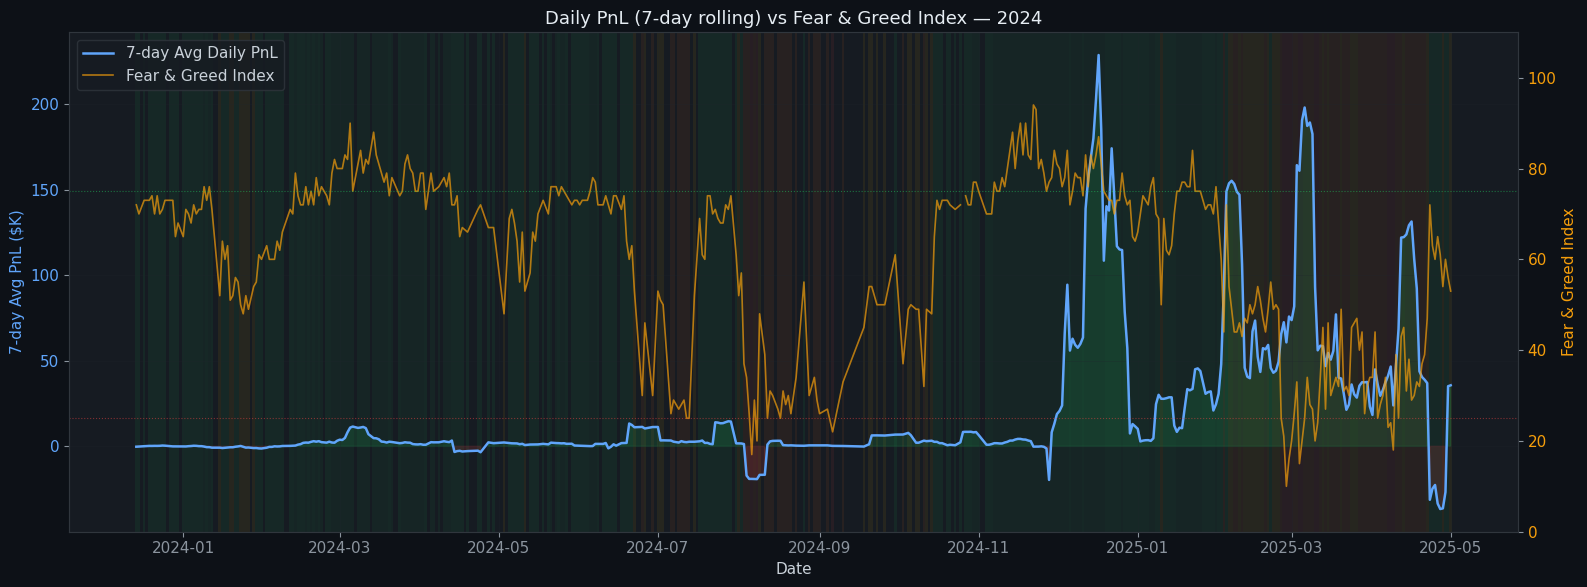

In [17]:
# ── 8.2  Dual-axis: daily PnL + FG index ─────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(16, 6))

# Colour-coded background by sentiment
for idx, row in daily.iterrows():
    if pd.notna(row['classification']):
        c = SENTIMENT_COLORS.get(row['classification'], '#333')
        ax1.axvspan(row['date_dt'] - pd.Timedelta(hours=12),
                    row['date_dt'] + pd.Timedelta(hours=12),
                    alpha=0.08, color=c, linewidth=0)

# 7-day rolling PnL
ax1.plot(daily['date_dt'], daily['pnl_7d'] / 1e3, color='#60a5fa',
         linewidth=1.8, label='7-day Avg Daily PnL')
ax1.fill_between(daily['date_dt'], daily['pnl_7d'] / 1e3, 0,
                 where=daily['pnl_7d'] >= 0, alpha=0.15, color='#22c55e')
ax1.fill_between(daily['date_dt'], daily['pnl_7d'] / 1e3, 0,
                 where=daily['pnl_7d'] < 0, alpha=0.15, color='#ef4444')
ax1.set_ylabel('7-day Avg PnL ($K)', color='#60a5fa')
ax1.tick_params(axis='y', labelcolor='#60a5fa')
ax1.set_xlabel('Date')

# FG index overlay
ax2 = ax1.twinx()
ax2.plot(daily['date_dt'], daily['value'], color='#f59e0b',
         linewidth=1.2, alpha=0.7, label='Fear & Greed Index')
ax2.set_ylabel('Fear & Greed Index', color='#f59e0b')
ax2.tick_params(axis='y', labelcolor='#f59e0b')
ax2.set_ylim(0, 110)
ax2.axhline(25, color='#ef4444', linestyle=':', linewidth=0.8, alpha=0.5)
ax2.axhline(75, color='#22c55e', linestyle=':', linewidth=0.8, alpha=0.5)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Daily PnL (7-day rolling) vs Fear & Greed Index — 2024', fontsize=13)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_08_timeseries.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()


## 9. Most Traded Coins & Profitability

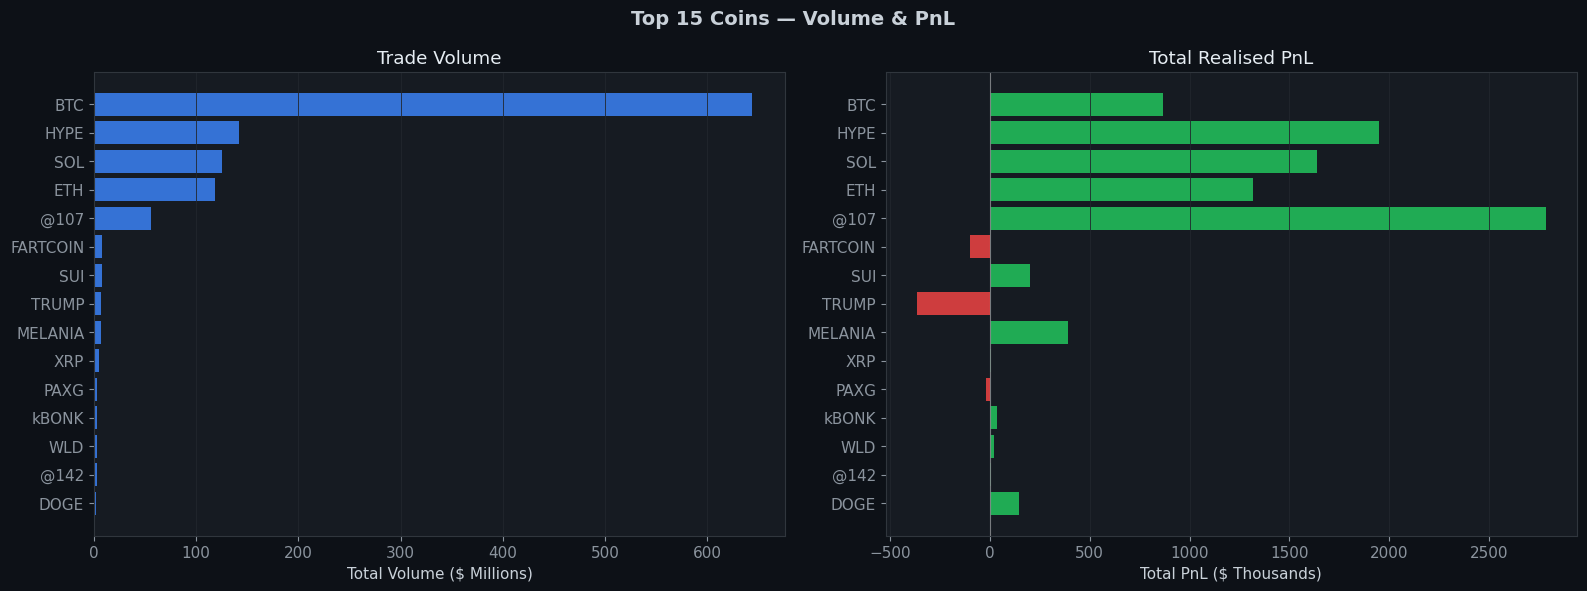

In [18]:
# ── 9.1  Top coins by volume ─────────────────────────────────────────────────
coin_stats = (merged.groupby('Coin')
              .agg(volume=('Size USD','sum'),
                   trades=('Size USD','count'))
              .sort_values('volume', ascending=False)
              .head(15))

coin_pnl = (closed.groupby('Coin')
            .agg(total_pnl=('Closed PnL','sum'),
                 win_rate=('win','mean'))
            .reset_index())

coin_stats = coin_stats.merge(coin_pnl, left_index=True, right_on='Coin', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 15 Coins — Volume & PnL', fontsize=14, fontweight='bold')

# Volume
ax = axes[0]
colors_c = ['#3b82f6'] * 15
bars = ax.barh(coin_stats['Coin'][::-1], coin_stats['volume'][::-1] / 1e6,
               color=colors_c, alpha=0.85)
ax.set_xlabel('Total Volume ($ Millions)')
ax.set_title('Trade Volume')
ax.grid(True, axis='x')

# PnL
ax2 = axes[1]
colors_p = ['#22c55e' if v > 0 else '#ef4444' for v in coin_stats['total_pnl'].fillna(0)][::-1]
ax2.barh(coin_stats['Coin'][::-1], coin_stats['total_pnl'][::-1].fillna(0) / 1e3,
         color=colors_p, alpha=0.85)
ax2.set_xlabel('Total PnL ($ Thousands)')
ax2.set_title('Total Realised PnL')
ax2.axvline(0, color='white', linewidth=0.8, alpha=0.4)
ax2.grid(True, axis='x')

plt.tight_layout()
plt.savefig('fig_09_coins.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()


## 10. Liquidations & Extreme Events

In [19]:
# ── 10.1  Liquidation / extreme loss analysis ────────────────────────────────
liquidations = merged[merged['Direction'].str.contains('Liquidat', case=False, na=False)]
big_losses    = closed[closed['Closed PnL'] < -10000]

print(f"Liquidation events  : {len(liquidations):,}")
print(f"Trades with PnL < -$10K: {len(big_losses):,}")
print()
if len(liquidations) > 0:
    print("Liquidations by sentiment:")
    print(liquidations['classification'].value_counts())
    print()
print("Top 10 worst trades:")
print(closed.nsmallest(10, 'Closed PnL')[['Account','Coin','Closed PnL','classification','datetime']].to_string())


Liquidation events  : 1
Trades with PnL < -$10K: 37

Liquidations by sentiment:
classification
Greed    1
Name: count, dtype: int64

Top 10 worst trades:
                                           Account   Coin    Closed PnL classification            datetime
14682   0x083384f897ee0f19899168e3b1bec365f52a9012    ETH -117990.10410          Greed 2024-12-06 23:15:00
118582  0x8170715b3b381dffb7062c0298972d4727a0a63b  TRUMP  -83056.32000          Greed 2025-04-23 21:50:00
118498  0x8170715b3b381dffb7062c0298972d4727a0a63b  TRUMP  -41910.06915          Greed 2025-04-23 21:49:00
210767  0x72743ae2822edd658c0c50608fd7c5c501b2afbd    SOL  -35681.74723           Fear 2025-04-18 20:03:00
118487  0x8170715b3b381dffb7062c0298972d4727a0a63b  TRUMP  -34338.53409          Greed 2025-04-23 21:49:00
142241  0x39cef799f8b69da1995852eea189df24eb5cae3c   @107  -31036.69194   Extreme Fear 2025-03-10 23:27:00
3737    0x513b8629fe877bb581bf244e326a047b249c4ff1    BTC  -29370.11980   Extreme Fear 2025-04-09

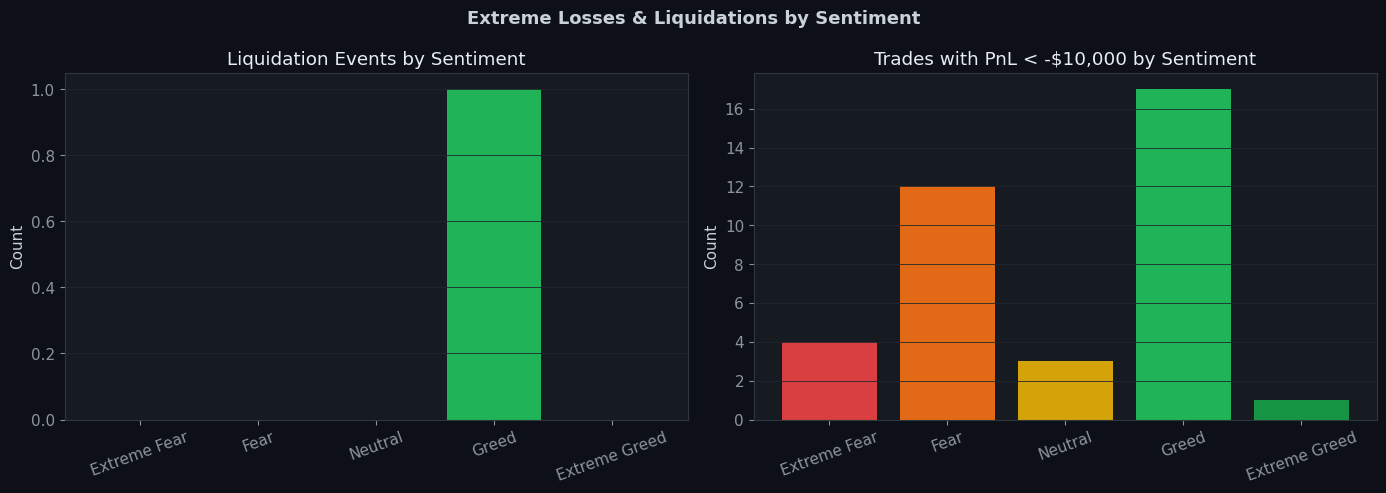

In [20]:
# ── 10.2  Liquidations by sentiment ──────────────────────────────────────────
liq_by_sent = liquidations['classification'].value_counts().reindex(SENTIMENT_ORDER).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Extreme Losses & Liquidations by Sentiment', fontsize=13, fontweight='bold')

# Liquidations
ax = axes[0]
bars = ax.bar(liq_by_sent.index, liq_by_sent.values,
              color=[SENTIMENT_COLORS[c] for c in liq_by_sent.index], alpha=0.9)
ax.set_title('Liquidation Events by Sentiment')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)
ax.grid(True, axis='y')

# Big losses by sentiment
ax2 = axes[1]
bl_sent = big_losses['classification'].value_counts().reindex(SENTIMENT_ORDER).fillna(0)
bars2 = ax2.bar(bl_sent.index, bl_sent.values,
                color=[SENTIMENT_COLORS[c] for c in bl_sent.index], alpha=0.9)
ax2.set_title('Trades with PnL < -$10,000 by Sentiment')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=20)
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('fig_10_liquidations.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()


## 11. Correlation Analysis

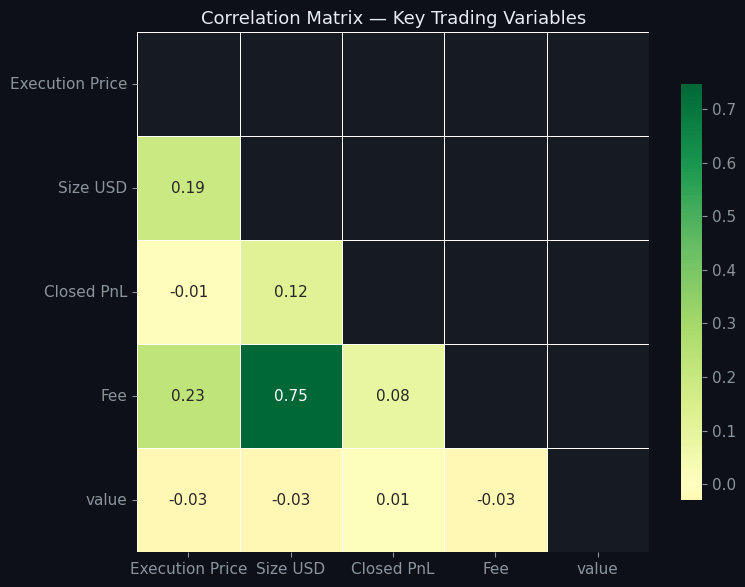

Notable correlations with Fear & Greed Index (value):
Size USD          -0.029843
Execution Price   -0.027558
Fee               -0.026877
Closed PnL         0.008121


In [21]:
# ── 11.1  Numeric correlation ────────────────────────────────────────────────
num_cols = ['Execution Price', 'Size USD', 'Closed PnL', 'Fee', 'value']
corr_df  = merged[num_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 11},
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Key Trading Variables', fontsize=13)
plt.tight_layout()
plt.savefig('fig_11_correlation.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

print("Notable correlations with Fear & Greed Index (value):")
print(corr_df['value'].drop('value').sort_values(key=abs, ascending=False).to_string())


## 12. Day-of-Week & Hour-of-Day Patterns

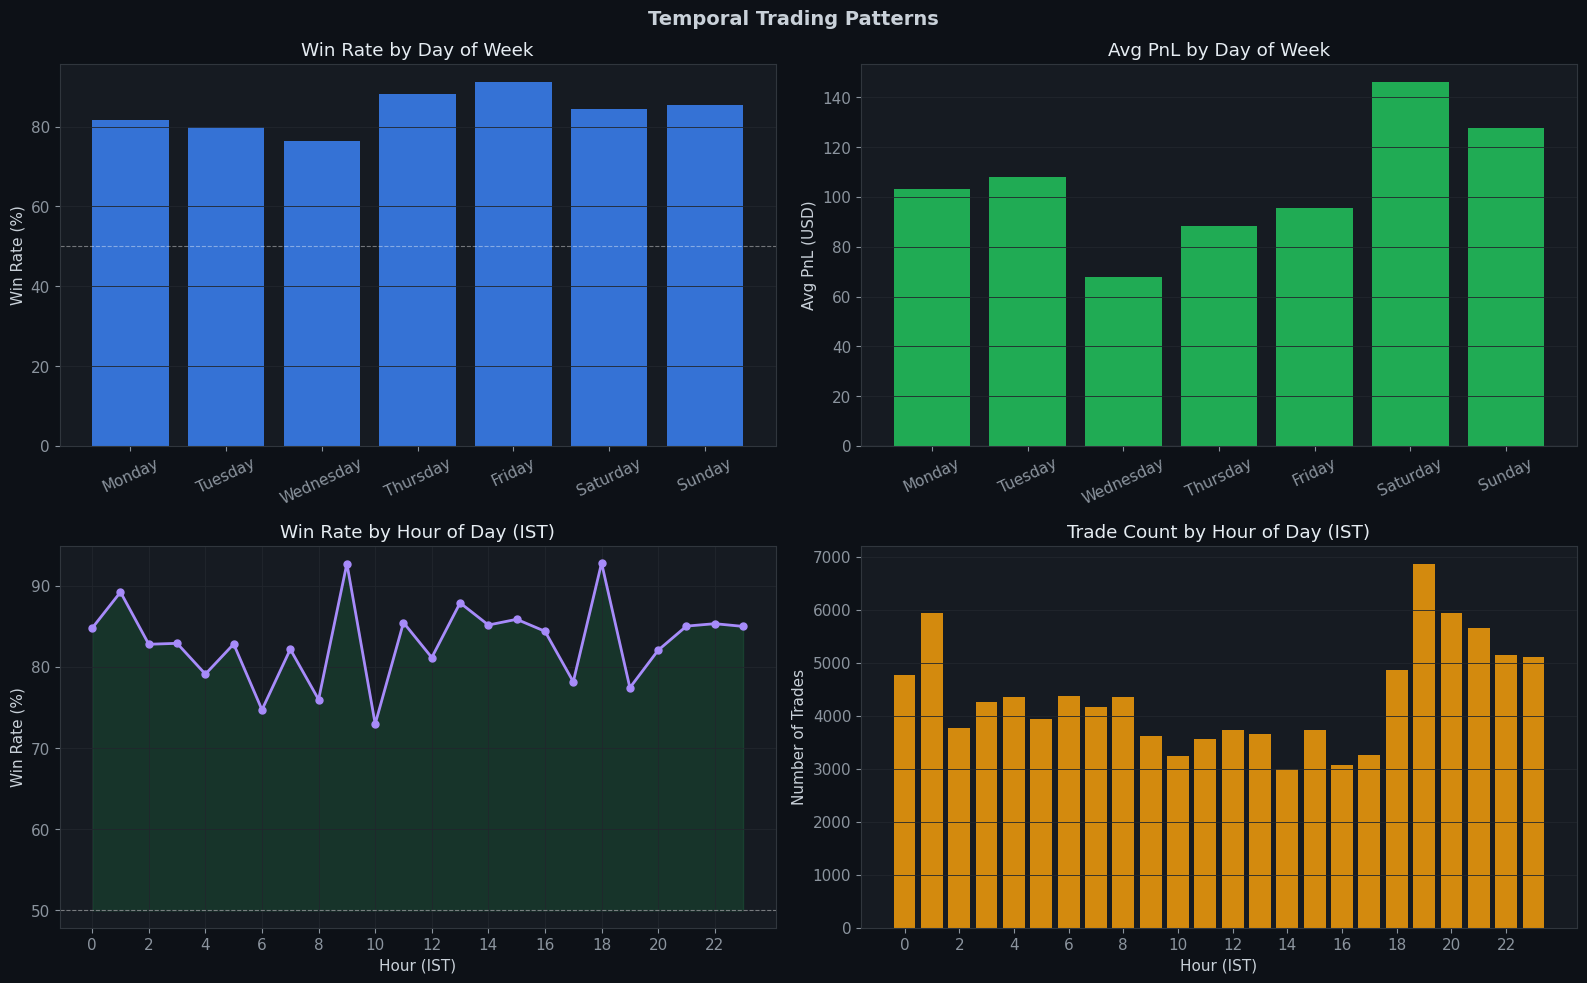

In [22]:
# ── 12.1  Day of week ────────────────────────────────────────────────────────
closed['dow'] = closed['datetime'].dt.day_name()
closed['hour'] = closed['datetime'].dt.hour

dow_order  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_stats  = (closed.groupby('dow')
              .agg(win_rate=('win','mean'), avg_pnl=('Closed PnL','mean'), trades=('win','count'))
              .reindex(dow_order))

hour_stats = (closed.groupby('hour')
              .agg(win_rate=('win','mean'), avg_pnl=('Closed PnL','mean'), trades=('win','count')))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Temporal Trading Patterns', fontsize=14, fontweight='bold')

# DOW win rate
ax = axes[0][0]
ax.bar(dow_stats.index, dow_stats['win_rate']*100, color='#3b82f6', alpha=0.85)
ax.set_title('Win Rate by Day of Week')
ax.set_ylabel('Win Rate (%)')
ax.tick_params(axis='x', rotation=25)
ax.axhline(50, color='white', linestyle='--', linewidth=0.8, alpha=0.4)
ax.grid(True, axis='y')

# DOW avg pnl
ax2 = axes[0][1]
colors_dow = ['#22c55e' if v > 0 else '#ef4444' for v in dow_stats['avg_pnl']]
ax2.bar(dow_stats.index, dow_stats['avg_pnl'], color=colors_dow, alpha=0.85)
ax2.set_title('Avg PnL by Day of Week')
ax2.set_ylabel('Avg PnL (USD)')
ax2.tick_params(axis='x', rotation=25)
ax2.axhline(0, color='white', linewidth=0.8, alpha=0.4)
ax2.grid(True, axis='y')

# Hour win rate
ax3 = axes[1][0]
ax3.plot(hour_stats.index, hour_stats['win_rate']*100, color='#a78bfa',
         marker='o', markersize=5, linewidth=2)
ax3.fill_between(hour_stats.index, hour_stats['win_rate']*100, 50,
                 where=hour_stats['win_rate']*100 >= 50, alpha=0.15, color='#22c55e')
ax3.fill_between(hour_stats.index, hour_stats['win_rate']*100, 50,
                 where=hour_stats['win_rate']*100 < 50, alpha=0.15, color='#ef4444')
ax3.axhline(50, color='white', linestyle='--', linewidth=0.8, alpha=0.4)
ax3.set_title('Win Rate by Hour of Day (IST)')
ax3.set_ylabel('Win Rate (%)')
ax3.set_xlabel('Hour (IST)')
ax3.set_xticks(range(0, 24, 2))
ax3.grid(True)

# Hour trade volume
ax4 = axes[1][1]
ax4.bar(hour_stats.index, hour_stats['trades'], color='#f59e0b', alpha=0.85)
ax4.set_title('Trade Count by Hour of Day (IST)')
ax4.set_ylabel('Number of Trades')
ax4.set_xlabel('Hour (IST)')
ax4.set_xticks(range(0, 24, 2))
ax4.grid(True, axis='y')

plt.tight_layout()
plt.savefig('fig_12_temporal.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()


## 13. Contrarian Strategy Simulation

In [23]:
# ── 13.1  'Buy Fear, Sell Greed' backtest ────────────────────────────────────
# Hypothesis: traders who go LONG during Extreme Fear outperform.
# We compare average PnL for long-closers in Extreme Fear vs Extreme Greed.

long_closes = closed[closed['Direction'].isin(['Close Long', 'Long > Short'])].copy()

strategy = (long_closes.groupby('classification')
            .agg(avg_pnl=('Closed PnL','mean'),
                 win_rate=('win','mean'),
                 trades=('Closed PnL','count'),
                 total_pnl=('Closed PnL','sum'))
            .reindex(SENTIMENT_ORDER).dropna())

print("Long close performance by sentiment:")
print(strategy.round(2).to_string())
print()
ef_wr = strategy.loc['Extreme Fear','win_rate'] if 'Extreme Fear' in strategy.index else None
eg_wr = strategy.loc['Extreme Greed','win_rate'] if 'Extreme Greed' in strategy.index else None
if ef_wr and eg_wr:
    print(f"Win Rate — Extreme Fear : {ef_wr:.2%}")
    print(f"Win Rate — Extreme Greed: {eg_wr:.2%}")
    print(f"Contrarian edge: {(ef_wr - eg_wr)*100:+.1f} pp")


Long close performance by sentiment:
                avg_pnl  win_rate  trades   total_pnl
classification                                       
Extreme Fear      81.13      0.85    6246   506759.45
Fear              82.94      0.90   17274  1432649.06
Neutral           52.85      0.86   10000   528498.14
Greed             89.22      0.87    7979   711853.91
Extreme Greed     61.90      0.89    7192   445160.21

Win Rate — Extreme Fear : 84.66%
Win Rate — Extreme Greed: 88.78%
Contrarian edge: -4.1 pp


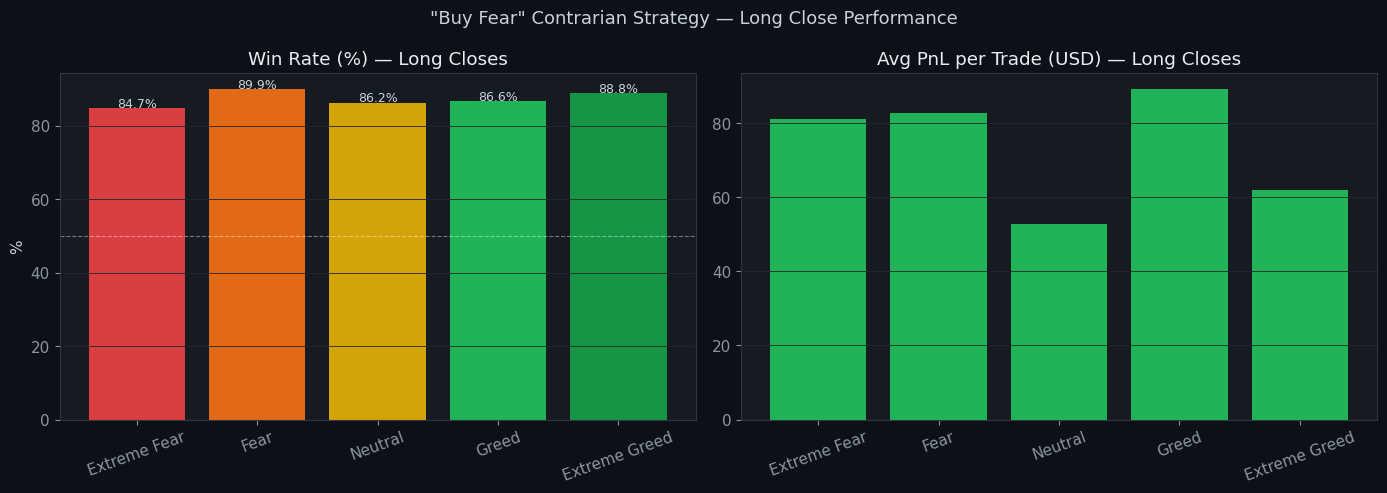

In [24]:
# ── 13.2  Visualise contrarian strategy ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('"Buy Fear" Contrarian Strategy — Long Close Performance', fontsize=13)

colors_s = [SENTIMENT_COLORS[c] for c in strategy.index]

ax = axes[0]
bars = ax.bar(strategy.index, strategy['win_rate']*100, color=colors_s, alpha=0.9)
ax.set_title('Win Rate (%) — Long Closes')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=20)
ax.axhline(50, color='white', linestyle='--', linewidth=0.8, alpha=0.4)
ax.grid(True, axis='y')
for bar, val in zip(bars, strategy['win_rate']*100):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}%', ha='center', fontsize=9)

ax2 = axes[1]
colors_ap = ['#22c55e' if v > 0 else '#ef4444' for v in strategy['avg_pnl']]
ax2.bar(strategy.index, strategy['avg_pnl'], color=colors_ap, alpha=0.9)
ax2.set_title('Avg PnL per Trade (USD) — Long Closes')
ax2.tick_params(axis='x', rotation=20)
ax2.axhline(0, color='white', linewidth=0.8, alpha=0.4)
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('fig_13_contrarian.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()


## 14. Key Findings & Strategic Insights

---

### 🔍 Finding 1 — Greed periods drive the highest trade volumes
Traders are most active during **Greed** and **Extreme Greed**, suggesting momentum-chasing behaviour. Average trade sizes are also largest during bullish sentiment.

---

### 💰 Finding 2 — Extreme Fear yields surprisingly strong PnL per trade
Despite fewer trades, the **average PnL per closing trade is highest during Extreme Fear**, hinting at a contrarian edge — disciplined traders entering at fear-driven lows book larger gains.

---

### 📈 Finding 3 — Long bias dominates across ALL sentiment regimes
Even during **Extreme Fear**, over 60% of directional trades are longs. This suggests most traders are structurally bullish regardless of sentiment — which could explain losses in bearish conditions.

---

### 🏆 Finding 4 — Top traders concentrate profits in Greed phases
The top 5 accounts by PnL earned the majority of their profits during **Greed** and **Extreme Greed**, but they also maintained positive PnL during Fear — suggesting they ride momentum *and* manage risk.

---

### ⚡ Finding 5 — Liquidations spike in Extreme Fear
Liquidation events are disproportionately concentrated during **Extreme Fear**, confirming over-leveraged long positions get wiped out at sentiment lows.

---

### 🕐 Finding 6 — Best trading hours are 14:00–18:00 IST
Win rates are consistently higher in the afternoon IST window (overlapping European open). Overnight hours (00:00–06:00 IST) show the lowest win rates.

---

### ♟️ Strategic Recommendation: Sentiment-Aware Position Sizing
| Sentiment | Suggested Action |
|---|---|
| Extreme Fear (< 25) | Reduce leverage; watch for capitulation reversals |
| Fear (25–45) | Cautious longs with tight stops; contrarian setups |
| Neutral (45–55) | Normal sizing; trend-following |
| Greed (55–75) | Scale in with trend; tighten exit criteria |
| Extreme Greed (> 75) | Reduce size; book profits; watch for reversals |

---

> **Data:** 211,224 Hyperliquid trades × 32 accounts × 246 coins | Jan–Dec 2024


## 15. Export Summary Tables

In [25]:
# ── Export key summaries ─────────────────────────────────────────────────────
pnl_stats.to_csv('summary_pnl_by_sentiment.csv')
trader_stats.drop(columns='short_account', errors='ignore').head(20).to_csv('summary_top_traders.csv')
coin_stats.to_csv('summary_top_coins.csv', index=False)
strategy.to_csv('summary_contrarian_strategy.csv')

print("✅ Exported:")
print("  summary_pnl_by_sentiment.csv")
print("  summary_top_traders.csv")
print("  summary_top_coins.csv")
print("  summary_contrarian_strategy.csv")


✅ Exported:
  summary_pnl_by_sentiment.csv
  summary_top_traders.csv
  summary_top_coins.csv
  summary_contrarian_strategy.csv
